### Checklist for submission

It is extremely important to make sure that:

1. Everything runs as expected (no bugs when running cells);
2. The output from each cell corresponds to its code (don't change any cell's contents without rerunning it afterwards);
3. All outputs are present (don't delete any of the outputs);
4. Fill in all the places that say `# YOUR CODE HERE`, or "**Your answer:** (fill in here)".
5. Never copy/paste any notebook cells. Inserting new cells is allowed, but it should not be necessary.
6. The notebook contains some hidden metadata which is important during our grading process. **Make sure not to corrupt any of this metadata!** The metadata may for example be corrupted if you copy/paste any notebook cells, or if you perform an unsuccessful git merge / git pull. It may also be pruned completely if using Google Colab, so watch out for this. Searching for "nbgrader" when opening the notebook in a text editor should take you to the important metadata entries.
7. Although we will try our very best to avoid this, it may happen that bugs are found after an assignment is released, and that we will push an updated version of the assignment to GitHub. If this happens, it is important that you update to the new version, while making sure the notebook metadata is properly updated as well. The safest way to make sure nothing gets messed up is to start from scratch on a clean updated version of the notebook, copy/pasting your code from the cells of the previous version into the cells of the new version.
8. If you need to have multiple parallel versions of this notebook, make sure not to move them to another directory.
9. Although not forced to work exclusively in the course `conda` environment, you need to make sure that the notebook will run in that environment, i.e. that you have not added any additional dependencies.

Failing to meet any of these requirements might lead to a request for resubmission if the errors are serious enough.

We advise you to perform the following steps before submission to ensure that requirements 1, 2, and 3 are always met: **Restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All). This might require a bit of time, so plan ahead for this (and possibly use a cloud GPU in HA1 and HA2 for this step). Finally press the "Save and Checkout" button before handing in, to make sure that all your changes are saved to this .ipynb file.

### Fill in name of notebook file
This might seem silly, but the version check below needs to know the filename of the current notebook, which is not trivial to find out programmatically.

You might want to have several parallel versions of the notebook, and it is fine to rename the notebook as long as it stays in the same directory. **However**, if you do rename it, you also need to update its own filename below:

In [1]:
nb_fname = "HA2-Part1.ipynb"

### Fill in group number and member names (use NAME2 and GROUP only for HA1 and HA2):

In [2]:
NAME1 = "Sreelekha Vuppala"
NAME2 = "Venkata Sai Sarat Chandra"
GROUP = "38"

### Check Python version

In [3]:
from platform import python_version_tuple

assert (
    python_version_tuple()[:2] == ("3", "11")
), "You are not running Python 3.11. Make sure to run Python through the course Conda environment."

### Check that notebook server has access to all required resources, and that notebook has not moved

In [4]:
import os

nb_dirname = os.path.abspath("")
assignment_name = os.path.basename(nb_dirname)
assert assignment_name in [
    "IHA1",
    "IHA2",
    "HA1",
    "HA2",
], "[ERROR] The notebook appears to have been moved from its original directory"

### Verify correct nb_fname

In [5]:
from IPython.display import HTML, display

try:
    display(
        HTML(
            r'<script>if("{nb_fname}" != IPython.notebook.notebook_name) {{ alert("You have filled in nb_fname = \"{nb_fname}\", but this does not seem to match the notebook filename \"" + IPython.notebook.notebook_name + "\"."); }}</script>'.format(
                nb_fname=nb_fname
            )
        )
    )
except NameError:
    assert False, "Make sure to fill in the nb_fname variable above!"

### Verify that your notebook is up-to-date and not corrupted in any way

In [6]:
import sys

sys.path.append("..")
from ha_utils import check_notebook_uptodate_and_not_corrupted

check_notebook_uptodate_and_not_corrupted(nb_dirname, nb_fname)

Matching current notebook against the following URL:
http://raw.githubusercontent.com/dml-cth/deep-machine-learning/master/home-assignments/HA2/HA2-Part1.ipynb
[SUCCESS] No major notebook mismatch found when comparing to latest GitHub version. (There might be minor updates, but even that is the case, submitting your work based on this notebook version would be acceptable.)


# HA2 - Recurrent Neural Networks

This assignment is divided into two parts. In the first one, you will implement a vanilla RNN module from scratch using PyTorch to perform the task of predicting the nationality of a given name. In the second, you will implement many of the components in a Transformer block, and use it to classify movie reviews as positive or negative. 

For efficient use of GPU hours, you can do all development up until the training on a CPU. You can then run the training on a GPU for faster training times.

**IMPORTANT NOTES:**
Some cells contain compiled tests. For them to work propery, make sure to keep function and class names.
Similarly to IHA1, IHA2 and HA1 some questions in this notebook will not be graded in detail, but we still expect you to answer them. Those questions are marked with (0 points) and, as well as the other questions in this notebook, they may appear in the Inspera test.
You won’t need to train neural networks in Inspera test.

# Task 1 - Predicting Nationalities

In this task, you will create an RNN module using PyTorch, and train it to predict the nationality of a given input name. Your RNN will process each character of an input name at a time, and at the last character output a probability mass function over the possible countries.

The data for this task is present in the file `data/nam_dict.txt`. After parsing it we will have around 44k names from 41 different countries.

---
## 1.0 Imports

Import all dependencies

In [7]:
from utils.tests import ha2_part1_tests
%load_ext autoreload
%autoreload 2

from utils.load_names import get_data_from_file

import matplotlib.pyplot as plt
import numpy as np
import torch

---
## 1.1 Loading the data

We'll start by loading the data from the `nam_dict.txt` file, using the provided method `get_data_from_file`.

In [8]:
names_dict = get_data_from_file("data/nam_dict.txt")

The newly-created variable `names_dict` is a dictionary where each country is a key, and the value is the corresponding list of names from that country.

In [9]:
names_dict.keys()

dict_keys(['Great Britain', 'Ireland', 'U.S.A.', 'Italy', 'Portugal', 'Spain', 'France', 'the Netherlands', 'East Frisia', 'Germany', 'Swiss', 'Iceland', 'Denmark', 'Norway', 'Sweden', 'Finland', 'Estonia', 'Latvia', 'Lithuania', 'Hungary', 'Romania', 'Bulgaria', 'Bosnia and Herzegovina', 'Croatia', 'Kosovo', 'Serbia', 'Albania', 'Greece', 'Russia', 'Ukraine', 'Armenia', 'Azerbaijan', 'Kazakhstan/Uzbekistan,etc.', 'Turkey', 'Arabia/Persia', 'Israel', 'China', 'India/Sri Lanka', 'Japan', 'Korea', 'Vietnam'])

In [10]:
names_dict["Greece"][:10]

['Achilleas',
 'Achillefs',
 'Adamantia',
 'Adamantini',
 'Adamantios',
 'Aeneas',
 'Afroditi',
 'Agapi',
 'Agapios',
 'Agathi']

Let's look at the dataset in more detail. Plot the number of names in each country using a [bar plot](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.bar.html).

*Hints*:

- You can put labels in the x-axis using the method [`xticks`](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.xticks.html).
- The `xticks` method accepts a keyword argument named `rotation`.

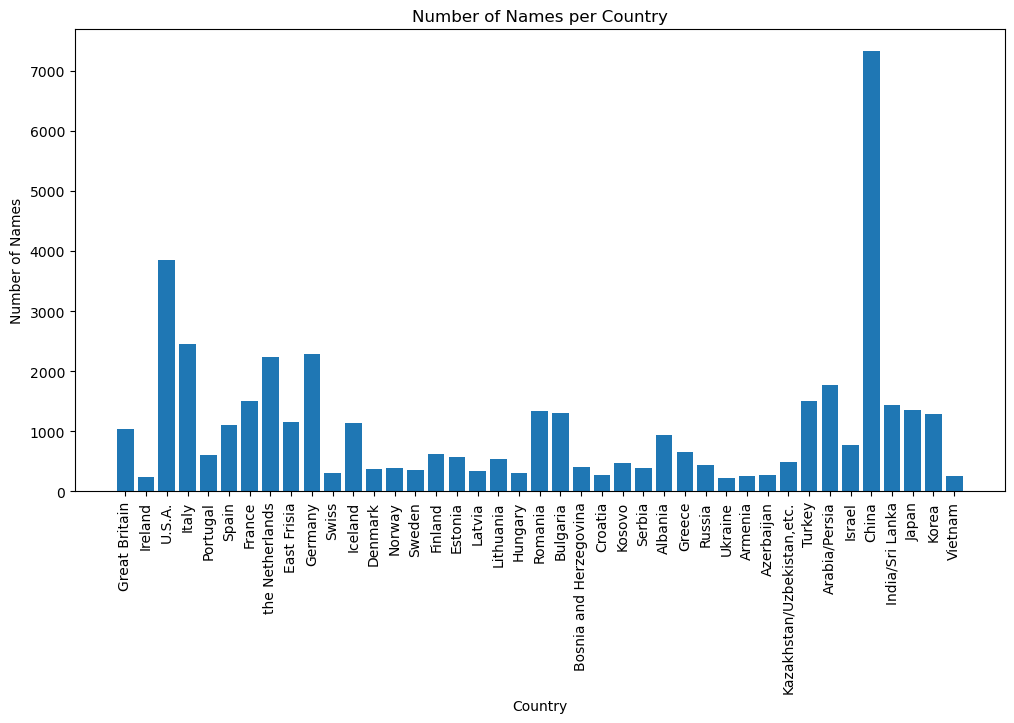

In [11]:
%matplotlib inline

# YOUR CODE HERE

country_counts = {country: len(names) for country, names in names_dict.items()}

countries = list(country_counts.keys())
counts = list(country_counts.values())

plt.figure(figsize=(12,6))
plt.bar(countries, counts)
plt.xticks(rotation=90)  
plt.xlabel("Country")
plt.ylabel("Number of Names")
plt.title("Number of Names per Country")
plt.show()


Is this dataset balanced? If not, which are the top-5 countries with most names?

**Your answer:** From the above bar chart , the dataset is clearly not balanced. A balanced dataset would imply a relatively even distribution of the "Number of Names" across all the listed countries. However, the chart shows extreme variation, with some countries having a very high number of names (e.g., China) and many others having very low numbers (close to or below 500). China , U.S.A , italy , Germany, Netherlands are top-5 countries with most names .

---
## 1.2 Pre-processing

We will train an RNN which takes as input one character at each time-step. In order to do so, we will encode every character in the input names into a one-hot representation that is more suited to be fed to neural networks. 

The first thing we need to do is to decide the size of the alphabet used for the one-hot encoding. To do so, let's take a look at all the characters used in the dataset. A simple way to do so is putting all names in the same string and then using a `set` to get the unique values. We'll treat upper-case and lower-case characters as being the same.

In [12]:
temp = " "
for name_list in names_dict.values():
    for name in name_list:
        temp += name.lower()
charset = sorted(set(temp))
print(f"{len(charset)} characters:")
charset

57 characters:


[' ',
 "'",
 '-',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 'ß',
 'à',
 'á',
 'â',
 'ã',
 'ä',
 'å',
 'æ',
 'ç',
 'è',
 'é',
 'ê',
 'ë',
 'í',
 'î',
 'ï',
 'ð',
 'ñ',
 'ò',
 'ó',
 'ô',
 'õ',
 'ö',
 'ø',
 'ú',
 'ü',
 'ý',
 'þ']

We will now create a function that takes as input a name and the set of characters, and outputs a `(name length) x (charset length)` tensor, with each row being a one-hot encoding of the corresponding character. Complete the function below.

In [13]:
def name2tensor(name, charset):
    name = name.lower()

    tensor = None
    # YOUR CODE HERE
    
    charset_size = len(charset)

    char2index = {char: idx for idx, char in enumerate(charset)}

    tensor = torch.zeros(len(name), charset_size, dtype=torch.float)

    for i, char in enumerate(name):
        if char in char2index:
            tensor[i, char2index[char]] = 1.0
        else:
            pass
    
    return tensor

Run the following cell without changing anything to test your implementation of the above method. 

In [14]:
ha2_part1_tests.test_name2_tensor(name2tensor)

Test passed


Let us look at an example tensor for a name.

In [15]:
name2tensor("Ali", charset)

tensor([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])

Why does the above output tensor contain a 1 at position (0,3)?

**Your answer:** The tensor has a 1 at position (0,3) because the name "Ali" is first converted to lowercase, becoming "ali". The first character in the name is 'a', which corresponds to index 3 in the list of all unique characters (charset). When we convert characters to one-hot vectors, we set a 1 in the position that matches the character’s index in the charset, and all other positions are 0. Since 'a' is the first character, this 1 appears in row 0 of the tensor and column 3, marking the presence of 'a'.

What would happen if you try encoding the string `Lol@` using this function? Why?

**Your answer:** If we try to encode the string "Lol@" using this function, the characters that are in the charset, like 'l' and 'o', will be converted to one-hot vectors normally. However, the '@' symbol is not in the charset(not listed in 57 characters ), so the function cannot encode it and will simply ignore it. This means the resulting tensor will only have rows for 'l', 'o', and 'l', and there will be no representation for '@'.

It's definitely possible to use the tensors created with `name2tensor` to train our RNN, but in that case we would only be able to conveniently perform forward-propagation using one sample at a time.

Instead, we want to batch samples together and parallelize the forward-propagation step. To do so, all samples must have the same dimensions (right now every sample has dimension `(name length) x (charset length)`, and the length of the names varies). Modify the function `name2padded_tensor` to achieve this by padding the start of the tensor with zeros, so that the output tensor always has length `target_len x (charset length)`.

*Hint*:

- To make it easier to catch bugs in the next parts of the assignment, make sure to raise an exception if the `target_len` is smaller than the length of the input word.

In [16]:
def name2padded_tensor(name, target_len, charset):
    tensor = name2tensor(name, charset)

    # YOUR CODE HERE

    name_len = tensor.size(0)
    charset_size = tensor.size(1)

    if name_len > target_len:
        raise ValueError(f"Target length {target_len} is smaller than the name length {name_len}")

    if name_len < target_len:
       padding = torch.zeros(target_len - name_len, charset_size, dtype=torch.float)
       tensor = torch.cat([padding, tensor], dim=0)

    return tensor

In [17]:
ha2_part1_tests.test_name2padded_tensor(name2padded_tensor, charset)

Test passed.


What should be the target length for our case in this dataset? Compute it (i.e. don't hardcode it) in the cell below and save it in a variable named `target_len`, which will be used from here on

In [18]:
# YOUR CODE HERE

target_len = max(len(name) for names in names_dict.values() for name in names)

print(f"Target length for padding: {target_len}")

Target length for padding: 22


In [19]:
ha2_part1_tests.test_target_len(target_len)

Test passed


Now we can go through the entire dataset, encode each of the names, and save all of it in a tensor. We'll do the same with the ground-truth labels for the countries of each name.

In [20]:
# Create the tensors that will hold the names and labels
# (note that the first dimension has 0 elements, this is a way to initialize an empty tensor for concatenating later)
xs = torch.zeros(0, target_len, len(charset))
ys = torch.zeros(0, dtype=torch.long)

for i, country in enumerate(names_dict.keys()):
    # Apply the name2padded_tensor function to each name in this country
    temp = map(lambda n: name2padded_tensor(n, target_len, charset), names_dict[country])

    # Add a new dimension to the resulting tensors
    temp = [name_tensor[None, :, :] for name_tensor in temp]

    # Concatenate all of them along this new dimension
    names_tensor = torch.cat(temp, dim=0)

    # Add these tensors to `xs`
    # Note that we have 44504 data pairs (x,y) where a single input x has the shape (target_len, 57),
    # where 57 is the length of the one-hot-encoded vectors.
    xs = torch.cat([xs, names_tensor], dim=0)

    # Create tensor filled with i`s and add that to the ground-truth tensor
    ys_for_this_country = torch.zeros(names_tensor.shape[0], dtype=torch.long) + i
    ys = torch.cat([ys, ys_for_this_country])

In [21]:
xs.shape

torch.Size([44504, 22, 57])

In [22]:
ys.shape

torch.Size([44504])

Now we can create a dataset with these tensors.

In [23]:
from torch.utils.data import TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")
dataset = TensorDataset(xs.to(device), ys.to(device))

Using cpu


And split it in training, validation, and test sets.

In [24]:
from torch.utils.data import random_split

val_ratio = 0.15
test_ratio = 0.15

n_samples = len(dataset)
n_val_samples = int(n_samples * val_ratio)
n_test_samples = int(n_samples * test_ratio)
n_train_samples = n_samples - n_val_samples - n_test_samples

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [n_train_samples, n_val_samples, n_test_samples]
)

---
### 1.3 Defining the optimization

Now we will define the model to be trained, that is, a single layer RNN. As usual, we will create a class for the model and inherit from `nn.Module`. Define in the next cell a class for an RNN that follows the equations:

$$ h_t = \text{tanh}(W_h x_t + U_h h_{t-1} + b_h) $$
$$ y_t = \log \Big(\text{Softmax}(W_y h_t + b_y)\Big)~,$$

where $h_t$ is the current hidden-state, $h_{t-1}$ is the previous hidden state, $x_t$ is the input, $y_t$ is the output, and $W_h, U_h, b_h, W_y, b_y$ are the trainable parts of the RNN. As explained before, we will use this RNN to classify names, inputting one character at each step and using the last output as the prediction for a distribution over probable countries for the name.

*Hints:*

- As you're probably aware by now, PyTorch [has a layer](https://pytorch.org/docs/stable/nn.html#logsoftmax) that already applies the log and the softmax in one pass.
- If you get errors related to size mismatches when computing the forward-propagation in your model, try reading the documentation for the specific module where the problem is occurring (e.g. [`nn.Linear`](https://pytorch.org/docs/stable/nn.html#linear)), especially the part about the expected shape of inputs and outputs.

In [25]:
import torch.nn as nn


class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        """
        Inputs:
            input_size     - Dimensionality of the input of this RNN.
            hidden_size    - Dimensionality of the hidden state.
            output_size    - Dimensionality of the output of this RNN.
        """

        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        # YOUR CODE HERE
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)

        self.h2y = nn.Linear(hidden_size, output_size)

        self.log_softmax = nn.LogSoftmax(dim=1)
    def forward(self, x, h):
        """
        Runs the RNN module for one time-step.
        Inputs:
            x              - Batch of one-hot encoded characters.
                             Tensor of size (BATCH SIZE x CHARSET LENGTH).
            h              - Batch of hidden states at previous time-step.
                             Tensor of size (BATCH SIZE x `hidden_size`).

        Returns:
            y              - Batch of outputs.
                             Tensor of size (BATCH SIZE x NUMBER OF COUNTRIES).
            new_h          - Batch of hidden states at current time-step.
                             Tensor of size (BATCH SIZE x `hidden_size`).
        """

        # YOUR CODE HERE
        combined = torch.cat((x, h), dim=1)

        new_h = torch.tanh(self.i2h(combined))

        y = self.h2y(new_h)                     
        y = self.log_softmax(y)

        return y, new_h

Run the following cell to test whether the shape of your outputs are correct. Note that this *only* checks the shapes and some basic ranges of outputs, not the content (one way you can check the actual computations of your network is to `print` the tensors as they pass through the layers, in order to check that the computations do what you expected).

In [26]:
ha2_part1_tests.test_model_output(RNN, device, names_dict, charset)

Test passed.


Suppose we now create an RNN using the following call: `RNN(x, y, z)`. How many parameters would this model have in total?

**Your answer:** The RNN has three main sets of trainable parameters. First, there are the weights and bias for the hidden state: W_h multiplies the input and has y*x parameters, U_h multiplies the previous hidden state and has y*y parameters, and the bias b_h has y parameters. Second, there are the weights and bias for the output layer: W_y multiplies the hidden state and has z*y parameters, and the bias b_y has z parameters. Here, x is the input size, y is the hidden size, and z is the output size. Adding all of these together, the total number of parameters in the model is y*x + y*y + y + z*y + z.

We will use the Adam optimizer:

In [27]:
from torch.optim import Adam

And, since this is a classification problem we will use the negative log-likelihood loss ([`NLLLoss`](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html#torch.nn.NLLLoss)) to train the model. We should account for the fact that our dataset is imbalanced, and one way of dealing with this problem is to assign different weights to each class in our problem. More specifically, we want to give higher weights to examples belonging to the less frequent classes and lower weights to the more frequent ones.

In [28]:
# Compute weights for each class
n_names_for_each_country = [len(v) for v in names_dict.values()]
ns = torch.tensor(n_names_for_each_country, dtype=torch.float)
w = 1.0 / ns
w = w / w.sum()

Declare the appropriate weight criterion using the weights defined above.

In [29]:
# Define loss

criterion = None
# YOUR CODE HERE

criterion = nn.NLLLoss(weight=w.to(device))

In [30]:
ha2_part1_tests.test_criterion(criterion, device)

Test passed.


Why is it a problem that the dataset is imbalanced? What would be the consequence of not dealing with this problem?

**Your answer:** An imbalanced dataset means some countries have a lot more names than others. If we don’t fix this, the model will mostly predict the common countries because it sees them more often. This makes the model unfair and it will often get the rare countries wrong. Even if the overall accuracy looks good, it won’t work well for the less frequent classes. The model might ignore important patterns in the rare countries. Using class weights helps the model pay attention to rare countries too. Without this, it will favor common countries and make more mistakes on uncommon ones.

Why does assigning different weights to each class solve this problem?

**Your answer:** Assigning different weights to each class helps because it makes the model treat mistakes on rare classes as more important. Normally, the model sees common classes more often, so it focuses on predicting them correctly and might ignore rare classes. By giving higher weights to rare classes, the loss becomes larger when the model gets them wrong. This forces the model to pay more attention to these less frequent classes during training. As a result, the model learns to balance its predictions and doesn’t just favor the common classes. In simple words, weighting helps the model care more about countries with fewer names, improving performance on all classes.

Is there any situation where *we would want* to introduce class imbalances in your dataset? How could we create such a class imbalance in a balanced dataset (without changing the dataset itself)?

**Your answer:** In given dataset, China has around 7,200 names, while some countries have fewer than 500 names. Suppose, For example  we wanted the model to focus more on countries like France or the Netherlands, which have about 2,250 names each. We could introduce an imbalance by over-sampling names from France and the Netherlands so they appear more frequently during training. Alternatively, we could under-sample names from China, reducing how often they appear in batches. We could also use weighted sampling(Assign probabilities to each sample so some classes are more likely to be selected during training.) in the DataLoader to make names from less frequent countries appear more often. This way, even though the dataset itself hasn’t changed, the model effectively sees some countries more or less frequently, creating a controlled imbalance.

---
### 1.4 Helper functions for training

Now that we defined the optimization problem, we can start creating the code to actually solve it. The first thing that we need is a function that, given a batch of samples, computes the output of the model for every sample and the average loss across all samples. 

Complete the function `batch_forward_prop` to produce this behavior.

*Hints*:

- Initialize the hidden state to a zero Tensor for the first forward-propagation.
- If you get errors related to size mismatches when computing the forward-propagation in your model, try reading the documentation for the specific module where the problem is occurring (e.g. [`nn.Linear`](https://pytorch.org/docs/stable/nn.html#linear)), especially the part about the expected shape of inputs and outputs.
- If you get errors related to size mismatches when computing the loss, try reading the [documentation for it](https://pytorch.org/docs/stable/nn.html#nllloss), especially the part about the expected shape of inputs and outputs.


In [31]:
def batch_forward_prop(rnn, xs, ys):
    """
    Inputs:
        rnn            - The RNN model, instance of the RNN class.
        xs             - Batch of input words.
                         Tensor of shape (BATCH SIZE x `target_len` x CHARSET LENGTH).
        ys             - Batch of ground-truth labels.
                         Tensor of  shape (BATCH_SIZE).

    Returns:
        output         - Output computed at the last character position in the batch.
                         Tensor of shape (BATCH_SIZE x NUMBER OF COUNTRIES).
        loss           - Value of the average loss across the predictions for this batch, later used for back-propagation.
                         Tensor with a single element inside.
    """

    # YOUR CODE HERE

    batch_size = xs.size(0)
    target_len = xs.size(1)

    # initialize hidden state with zeros
    h = torch.zeros(batch_size, rnn.hidden_size, device=xs.device)

    for t in range(target_len):
        x_t = xs[:, t, :]   # take the t-th character from every word in the batch
        output, h = rnn(x_t, h)  # forward through RNN

    loss = criterion(output, ys)


    return output, loss

Run the following cell to test whether the shape of your outputs are correct. Note that this *only* checks the shapes, not the content.

In [32]:
ha2_part1_tests.test_batch_forward_rnn(name2tensor_fn = name2tensor, 
                                       charset = charset,
                                       RNN_model = RNN,
                                       device = device,
                                       batch_forward_prop_fn = batch_forward_prop,
                                       names_dict = names_dict)

Test passed.


Using this function, it's straightforward to train on a single batch of data:

In [33]:
def train_batch(rnn, xs, ys, optimizer):
    # Compute the output for all samples in the batch and the average loss
    output, loss = batch_forward_prop(rnn, xs, ys)

    # Zero gradients before computing backward-propagation
    optimizer.zero_grad()

    # Backward-propagation
    loss.backward()

    # Clip the gradient norm (optional, helps to stabilize training)
    nn.utils.clip_grad_norm_(rnn.parameters(), 2)

    # Perform one step of optimization
    optimizer.step()

    return output, loss

We will also need a function for computing metrics of interest in the validation set. In this case, we will plot both the loss and the F1-score in the validation set. The F1-score of a classifier is the [harmonic mean](https://en.wikipedia.org/wiki/Harmonic_mean) of its [precision and recall](https://en.wikipedia.org/wiki/Precision_and_recall), two metrics that are more useful than accuracy for imbalanced datasets. [This blog post](https://towardsdatascience.com/accuracy-precision-recall-or-f1-331fb37c5cb9) can help you to familiarize yourself with these new metrics.

In [34]:
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics_on_validation_set(rnn, val_dataset):
    # Get all the input and labels in the validation set.
    x_val, y_val = val_dataset[:]

    # Perform forward-prop in the entire validation set, with autograd disabled
    with torch.no_grad():
        val_output, val_loss = batch_forward_prop(rnn, x_val, y_val)

    # Get numpy arrays for the true labels and the predictions
    y_true = y_val.cpu().numpy()
    y_pred = val_output.argmax(dim=1).cpu().numpy()

    # Compute precision, recall, and F-score
    precision, recall, fscore, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )

    return val_loss, precision, recall, fscore

Lastly, we define a function for plotting the metrics in real-time.

In [35]:
def plot_metrics(fig, ax, ns, train_losses, train_fscores, val_losses, val_fscores):
    # Plot losses
    ax[0].clear()
    ax[0].plot(ns, train_losses)
    ax[0].plot(ns, val_losses)
    ax[0].set_title("Loss")
    ax[0].legend(["Train", "Validation"])
    ax[0].set_xlabel("Number of trained batches")
    ax[0].grid()

    # Plot F1-scores
    ax[1].clear()
    ax[1].plot(ns, train_fscores)
    ax[1].plot(ns, val_fscores)
    ax[1].plot(ns, [0.3] * len(ns), "k--")
    ax[1].set_title("Macro F1-score")
    ax[1].legend(["Train", "Validation", "F1-score threshold"])
    ax[1].set_xlabel("Number of trained batches")
    ax[1].grid()

    fig.canvas.draw()

With these helper functions, the `train` function becomes:

In [36]:
from torch.utils.data import DataLoader
%matplotlib notebook

def train(rnn, n_epochs, learning_rate, batch_size, train_dataset, val_dataset):
    # Setup the figure for plotting progress during training
    
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
    plt.ion()
    plot_interval = 100

    # Create arrays to average training metrics across batches
    preds = []
    labels = []
    losses = []

    # Create dictionaries to hold the computed metrics in
    train_data = {"losses": [], "fscores": []}
    val_data = {"losses": [], "fscores": []}

    optimizer = Adam(rnn.parameters(), lr=learning_rate)
    train_data_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, drop_last=True
    )
    batch_idxs = []

    # Training loop
    i_batch = 0
    for n in range(n_epochs):
        for i, (x_batch, y_batch) in enumerate(train_data_loader):
            i_batch += 1

            # Compute loss and outputs
            output, loss = train_batch(rnn, x_batch, y_batch, optimizer)

            # Aggregate for later averaging
            preds += output.argmax(dim=1).cpu().tolist()
            labels += y_batch.cpu().tolist()
            losses.append(loss)

            # Compute metrics and plot after every `plot_interval` batches
            if i % plot_interval == 0:
                val_loss, _, _, val_fscore = compute_metrics_on_validation_set(
                    rnn, val_dataset
                )
                train_fscore = precision_recall_fscore_support(
                    labels, preds, average="macro"
                )[2]

                val_data["losses"].append(val_loss.cpu())
                val_data["fscores"].append(val_fscore)
                train_data["losses"].append((sum(losses) / len(losses)).item())
                train_data["fscores"].append(train_fscore)
                batch_idxs.append(i_batch)

                preds = []
                labels = []
                losses = []

                plot_metrics(
                    fig,
                    ax,
                    batch_idxs,
                    train_data["losses"],
                    train_data["fscores"],
                    val_data["losses"],
                    val_data["fscores"],
                )
                
        print(f"Last step validation loss: {val_loss:.3f}, F1-score: {val_fscore:.3f}")

Make sure that you completely understand the `train` function before proceeding (e.g. that we aggregate predictions from different batches and compute metrics only at a certain interval, etc).

---
### 1.5 Training!

Now we're ready to train the network! Create an RNN and use the `train` function to train it.

*Hints*:

- Tuning the hyper-parameters (number of hidden units, learning rate, batch size, etc) will take some trial-and-error. Try simple things first, and then once you manage to train them, start scaling up. Also, have in mind the bias-variance tradeoff mentioned in the lectures.
- When tuning the learning rate, focus first on being able to decrease the training loss. Keep decreasing the learning rate until that starts happening.
- You should use a GPU for fast training times. Using a CPU, training a network can take ~5-10 minutes with suitable hyper-parameters. With a GPU training takes ~1 minute with the same hyper-parameters.

**Note:** If the interactive plots don't work, try to downgrade the notebook as following:

```!pip install notebook==6.5 traitlets==5.9```

In [37]:
%matplotlib inline

/home/sreelekha/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sreelekha/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sreelekha/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

Last step validation loss: 2.903, F1-score: 0.183


/home/sreelekha/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Last step validation loss: 2.684, F1-score: 0.229
Last step validation loss: 2.622, F1-score: 0.223
Last step validation loss: 2.573, F1-score: 0.249
Last step validation loss: 2.543, F1-score: 0.260
Last step validation loss: 2.518, F1-score: 0.257
Last step validation loss: 2.458, F1-score: 0.275
Last step validation loss: 2.441, F1-score: 0.277
Last step validation loss: 2.409, F1-score: 0.289
Last step validation loss: 2.363, F1-score: 0.297
Last step validation loss: 2.413, F1-score: 0.295
Last step validation loss: 2.355, F1-score: 0.299
Last step validation loss: 2.326, F1-score: 0.301
Last step validation loss: 2.336, F1-score: 0.301
Last step validation loss: 2.395, F1-score: 0.283
Last step validation loss: 2.258, F1-score: 0.316
Last step validation loss: 2.260, F1-score: 0.318
Last step validation loss: 2.312, F1-score: 0.314
Last step validation loss: 2.281, F1-score: 0.320
Last step validation loss: 2.275, F1-score: 0.319


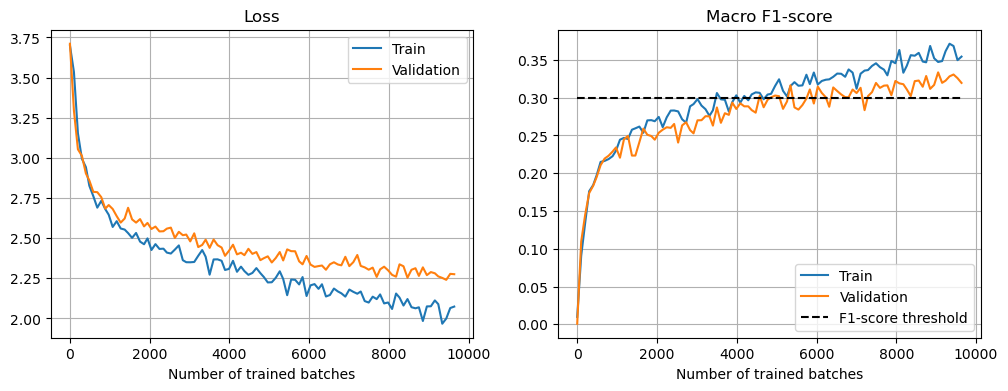

In [38]:
# YOUR CODE HERE

# Create the RNN model
input_size = len(charset)            
hidden_size = 512                  
output_size = len(names_dict)        

rnn = RNN(input_size, hidden_size, output_size)


device = torch.device("cpu")
rnn.to(device)

# Training hyperparameters
n_epochs = 20        
learning_rate = 0.001 
batch_size = 64      

# Train the model
train(rnn, n_epochs, learning_rate, batch_size, train_dataset, val_dataset)


In [39]:
_, _, _, fscore = compute_metrics_on_validation_set(rnn, val_dataset)
ha2_part1_tests.test_min_f1_score(fscore)

Test passed


---
### 1.6 Evaluation

Now that our model is trained, we can evaluate its predictions on the test set. 

In [40]:
# Get all samples from the test set
x_test, y_test = test_dataset[:]

# Compute predictions
with torch.no_grad():
    test_out, _ = batch_forward_prop(rnn, x_test, y_test)

# Transform them into hard predictions
preds = test_out.argmax(dim=1)

# Get `preds` as a numpy array
preds = preds.cpu().numpy()

Using these predictions, we can compute the confusion matrix on the test set as follows.

In [41]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
y_true = y_test.cpu().numpy()
cm = confusion_matrix(y_true, preds)
cm = cm.astype("float64")

# Normalize each row
for i in range(cm.shape[0]):
    cm[i, :] = cm[i, :] / sum(cm[i, :])

cm

array([[0.11258278, 0.04635762, 0.16556291, ..., 0.        , 0.02649007,
        0.01324503],
       [0.04761905, 0.07142857, 0.11904762, ..., 0.        , 0.        ,
        0.02380952],
       [0.03893805, 0.01061947, 0.18053097, ..., 0.01769912, 0.01061947,
        0.02123894],
       ...,
       [0.        , 0.        , 0.01428571, ..., 0.83809524, 0.        ,
        0.00952381],
       [0.        , 0.        , 0.        , ..., 0.00552486, 0.80110497,
        0.05524862],
       [0.        , 0.06      , 0.02      , ..., 0.        , 0.02      ,
        0.66      ]], shape=(41, 41))

In order to make this easier to visualize, let's plot it as a heat map:

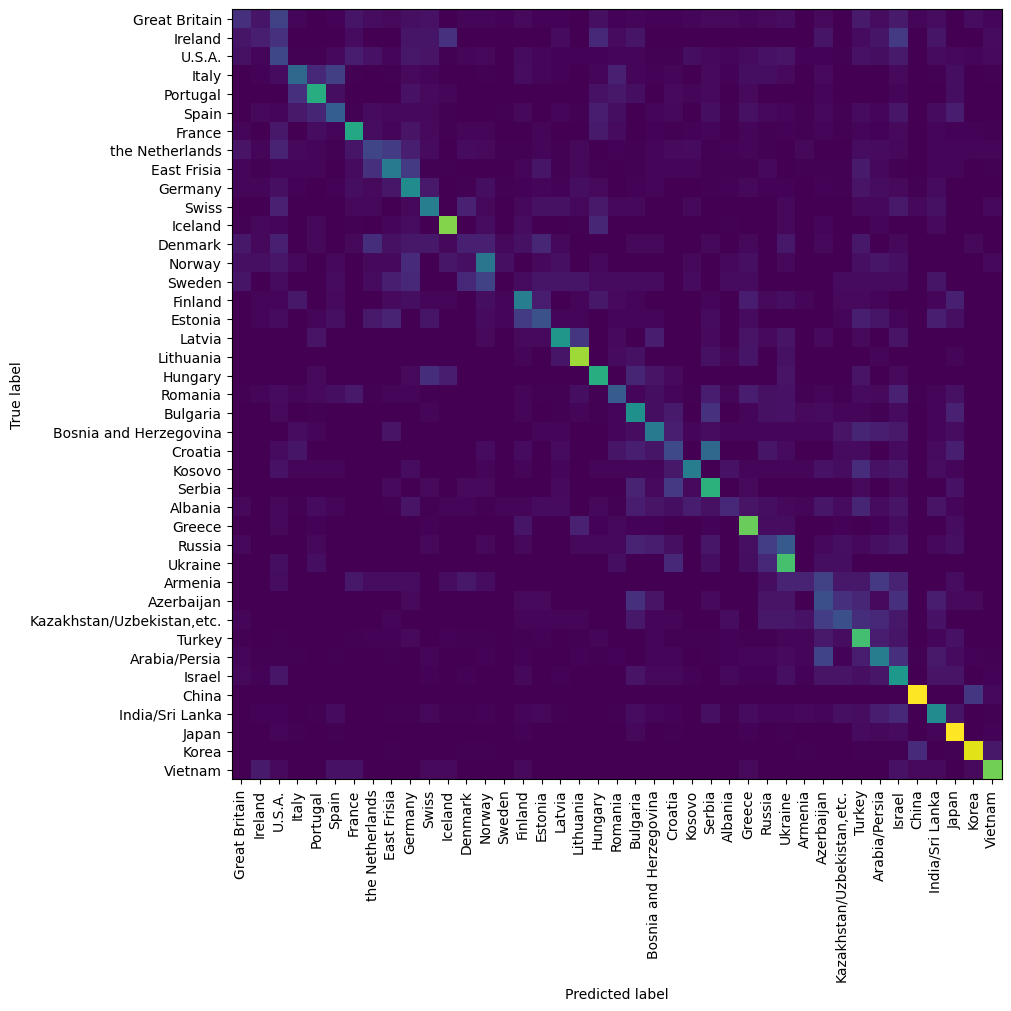

In [42]:
%matplotlib inline
plt.figure(figsize=(10, 10))
plt.imshow(cm)
plt.xticks(range(len(names_dict)), names_dict.keys(), rotation="vertical")
plt.yticks(range(len(names_dict)), names_dict.keys())
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

Why did we normalize the rows of the confusion matrix?

**Your answer:** We normalize the rows of the confusion matrix so that it is easier to understand and compare the model’s performance across different classes. Each row represents the true class and each column represents the predicted class. If we don’t normalize, the numbers just show counts, which can be misleading because some classes have more examples than others. By dividing each row by its total, we get fractions or percentages, showing the proportion of predictions for each true class. This makes it clear how often the model predicts correctly (the diagonal) and where it makes mistakes (off-diagonal), no matter how big or small each class is.

What can you conclude from this confusion matrix? Which classes are easy/hard to classify? Which classes are being confused? 

**Your answer:** From the above confusion matrix (heat map), it's clear that the classification model performs well overall, with a visible, bright diagonal indicating high accuracy for many classes. However, performance is highly uneven. The model finds certain classes very easy to classify, notably the East Asian countries of Vietnam, Korea, Japan, and China, as well as major Western nations like the U.S.A. and Great Britain, all of which show intense brightness concentrated on the diagonal. Conversely, the model struggles significantly with regional clusters, leading to major confusion. Key areas of difficulty include the Balkan countries (Bosnia and Herzegovina, Croatia, Serbia) which are frequently misclassified as one another, and the Central Asia/Middle East cluster, where Turkey, Arabia/Persia, and Kazakhstan/Uzbekistan, etc. show heavy off-diagonal misclassification. Furthermore, countries in Southwestern Europe like Portugal are often confused with Spain, with Italy also being drawn into this cluster. In summary, the model successfully distinguishes broad geographical regions but lacks the necessary specificity to reliably separate neighboring countries with shared cultural or geographical features.

To end this task, we can now define a function to perform predictions on any input name we provide (as long as the name contains only characters in our character set).

In [43]:
def evaluate(name_tensor):
    with torch.no_grad():
        hidden = torch.zeros(1, rnn.hidden_size).to(device)
        for i in range(name_tensor.shape[1]):
            output, hidden = rnn(name_tensor[:, i, :], hidden)
    return output.exp()


def predict(input_line, charset, n_predictions=5):
    tensor = name2tensor(input_line, charset).to(device)[None, :]
    output = evaluate(tensor)

    # Get top N categories
    topv, topi = output.topk(n_predictions, 1, True)
    topv, topi = topv[0], topi[0]

    cats = [list(names_dict.keys())[i] for i in topi.cpu().numpy()]
    vs = topv.cpu().numpy()

    plt.figure(figsize=(10, 3))
    plt.bar(range(len(vs)), vs)
    plt.xticks(range(len(vs)), cats)

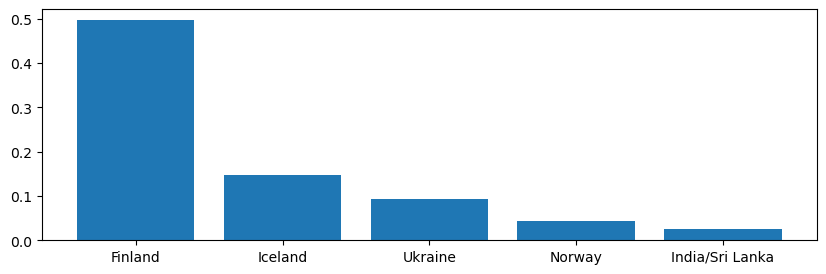

In [44]:
predict("Åsakvi", charset)

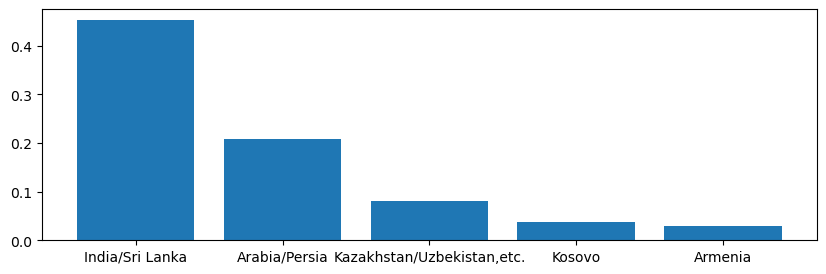

In [45]:
predict("Harakabim", charset)

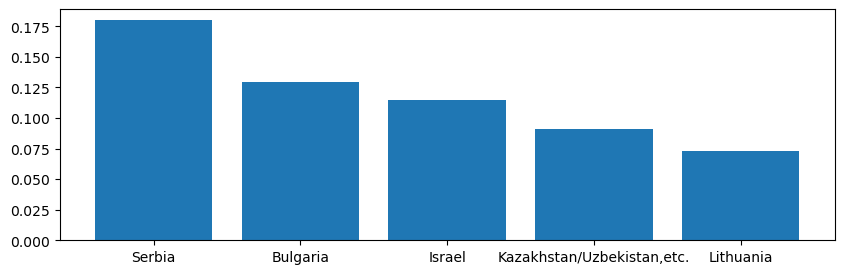

In [46]:
predict("Alakazam", charset)

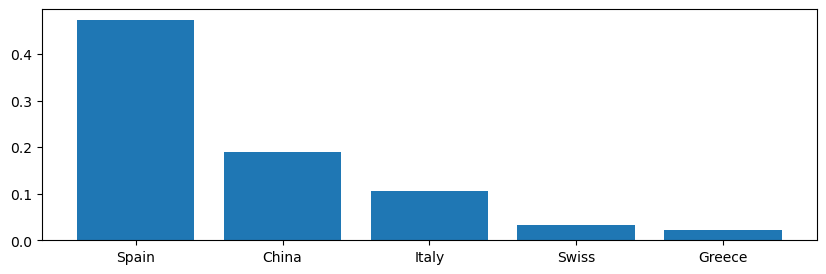

In [47]:
predict("Jin Quaio", charset)

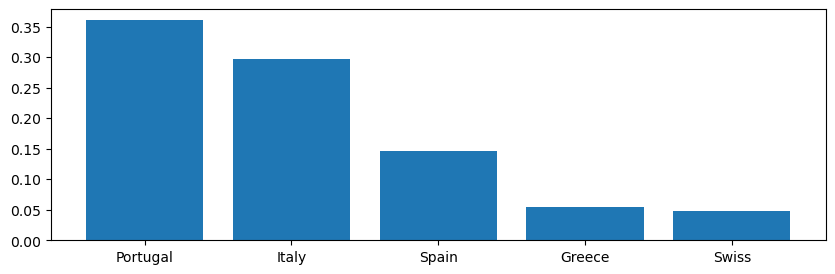

In [48]:
predict("Leonardino", charset)

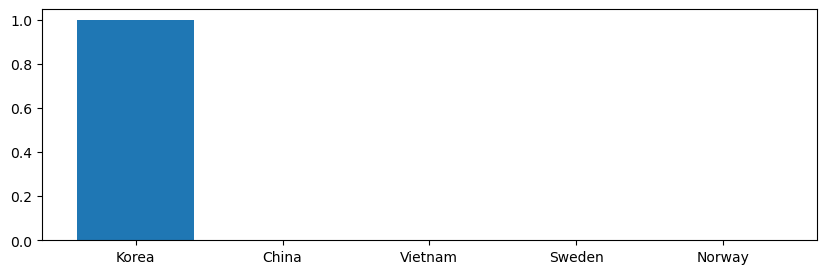

In [49]:
predict("Kim Sung", charset)

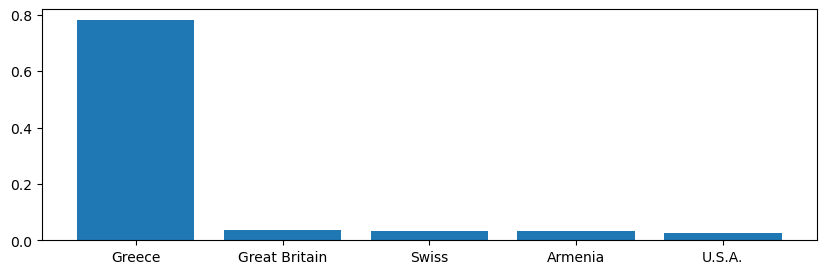

In [50]:
predict("Thanos", charset)

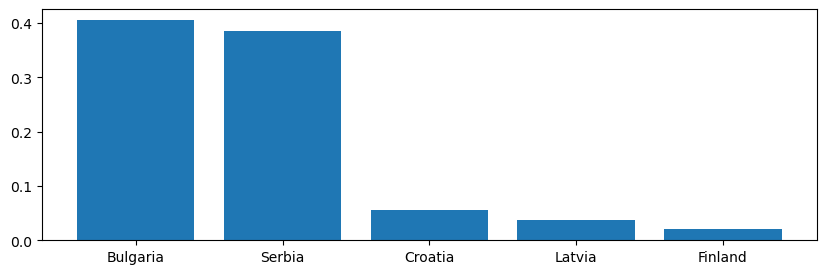

In [51]:
predict("Viiviika", charset)

Experiment on new names using the next cell:

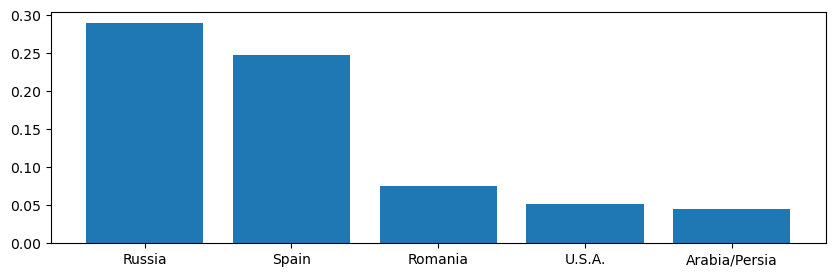

In [52]:
predict("Garcia", charset)

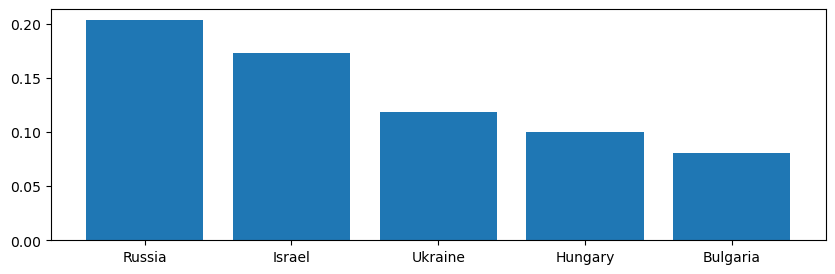

In [53]:
predict("Patel", charset)

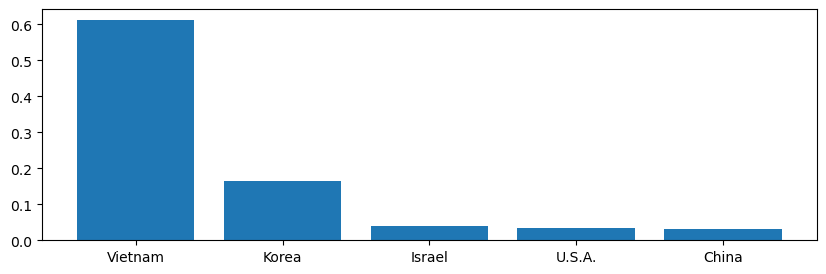

In [54]:
predict("Chen", charset)

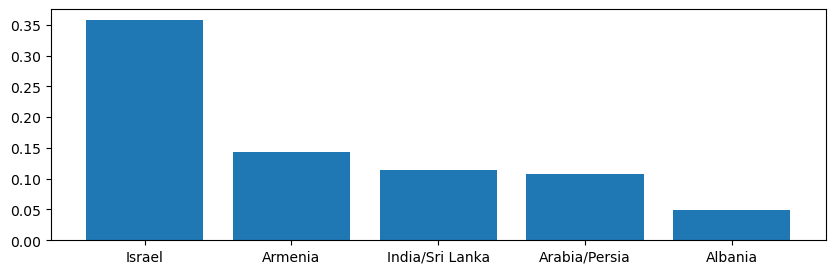

In [55]:
predict("rohith", charset)

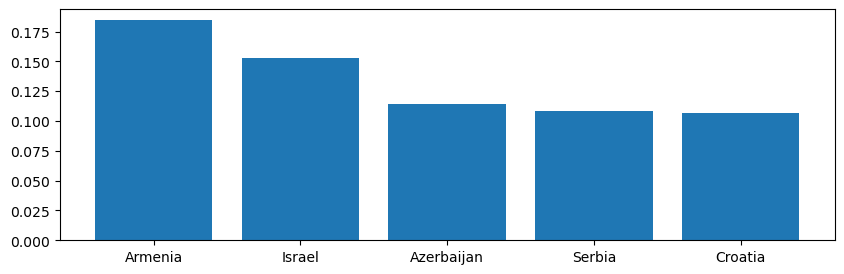

In [56]:
predict("ravan", charset)

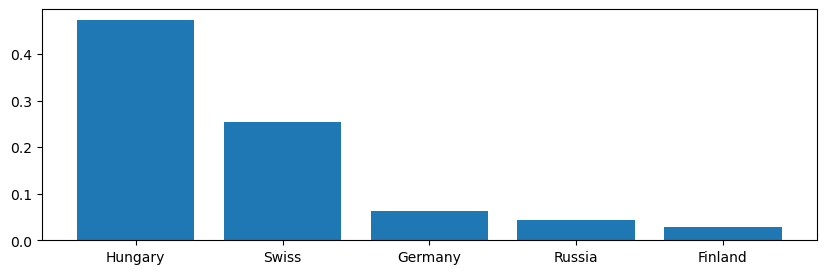

In [57]:
predict("Thomas Vikström", charset)

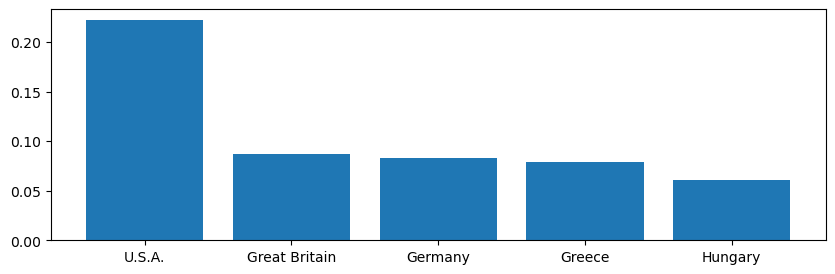

In [58]:
predict("andersson" , charset )